In [4]:
from matplotlib import pyplot as plt
import os
import pandas as pd
import numpy as np
import nibabel as nib
from skimage.feature import graycomatrix, graycoprops
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# ==============================================================================
# 1. CUSTOM TEXTURE EXTRACTION (GLCM)
# ==============================================================================
def extract_glcm_features(image_path, mask_path):
    try:
        # 1. Load the 3D MRI and the Mask using nibabel
        img_data = nib.load(image_path).get_fdata()
        mask_data = nib.load(mask_path).get_fdata()

        # 2. Find the 2D slice with the largest tumor area
        # (Since MRIs are 3D, we look at the slice where the mask is biggest)
        slice_areas = np.sum(mask_data, axis=(0, 1))
        best_slice_idx = np.argmax(slice_areas)

        # 3. Extract that specific 2D slice
        img_slice = img_data[:, :, best_slice_idx]
        mask_slice = mask_data[:, :, best_slice_idx]

        # 4. Apply the mask (turn background to 0, keep tumor pixels)
        tumor_only = img_slice * mask_slice

        # 5. Normalize image to integers (0-255) because GLCM requires integers
        tumor_normalized = np.interp(tumor_only, (tumor_only.min(), tumor_only.max()), (0, 255)).astype('uint8')

        # 6. Calculate the GLCM Texture Matrix
        # We look at pixels right next to each other (distance=[1], angles=[0])
        glcm = graycomatrix(tumor_normalized, distances=[1], angles=[0], levels=256, symmetric=True, normed=True)

        # 7. Extract the mathematical features from the matrix
        features = {
            'GLCM_Contrast': graycoprops(glcm, 'contrast')[0, 0],
            'GLCM_Correlation': graycoprops(glcm, 'correlation')[0, 0],
            'GLCM_Energy': graycoprops(glcm, 'energy')[0, 0],
            'GLCM_Homogeneity': graycoprops(glcm, 'homogeneity')[0, 0]
        }
        return features

    except Exception as e:
        print(f"  [!] Error processing {image_path}: {e}")
        return None



In [5]:
# ==============================================================================
# 2. LOOP THROUGH FOLDERS
# ==============================================================================
base_path = r"Processed NIFTI Dataset"
all_patients_data = []
MAX_PATIENTS_TO_TEST = 922 # Test with 5 first!

print("Starting custom GLCM feature extraction...")

for folder_name in os.listdir(base_path):
    if len(all_patients_data) >= MAX_PATIENTS_TO_TEST:
        break

    if folder_name.startswith("Breast_MRI"):
        print(f"Processing: {folder_name}...")
        folder_path = os.path.join(base_path, folder_name)
        image_file = os.path.join(folder_path, "post_1.img.gz")
        mask_file = os.path.join(folder_path, "segmentation.img.gz")

        if os.path.exists(image_file) and os.path.exists(mask_file):
            patient_features = extract_glcm_features(image_file, mask_file)
            if patient_features:
                patient_features['Patient_ID'] = folder_name
                all_patients_data.append(patient_features)

df_textures = pd.DataFrame(all_patients_data)
df_textures.to_csv("my_glcm_textures.csv", index=False)
print(f"\nExtraction complete for {len(df_textures)} patients! Saved to CSV.")

# NOTE: The Machine Learning training part remains exactly the same as the previous code!


Starting custom GLCM feature extraction...
Processing: Breast_MRI_001...
Processing: Breast_MRI_002...
Processing: Breast_MRI_003...
Processing: Breast_MRI_004...
Processing: Breast_MRI_005...
Processing: Breast_MRI_006...
Processing: Breast_MRI_007...
Processing: Breast_MRI_008...
Processing: Breast_MRI_009...
Processing: Breast_MRI_010...
Processing: Breast_MRI_011...
Processing: Breast_MRI_012...
Processing: Breast_MRI_013...
Processing: Breast_MRI_014...
Processing: Breast_MRI_015...
Processing: Breast_MRI_016...
Processing: Breast_MRI_017...
Processing: Breast_MRI_018...
Processing: Breast_MRI_019...
Processing: Breast_MRI_020...
Processing: Breast_MRI_021...
Processing: Breast_MRI_022...
Processing: Breast_MRI_023...
Processing: Breast_MRI_024...
Processing: Breast_MRI_025...
Processing: Breast_MRI_026...
Processing: Breast_MRI_027...
Processing: Breast_MRI_028...
Processing: Breast_MRI_029...
Processing: Breast_MRI_030...
Processing: Breast_MRI_031...
Processing: Breast_MRI_032.

In [6]:
# ==============================================================================
# 3. CONNECT TO MOLECULAR DATA & TRAIN AI
# ==============================================================================
import joblib
try:
    # 1. Load the Excel file
    df_clinical = pd.read_excel('Clinical_and_Other_Features.xlsx')

    # 2. Fix the "Double Header" trap in the Duke Dataset
    if 'Patient Information' in df_clinical.columns:
        df_clinical = pd.read_excel('Clinical_and_Other_Features.xlsx', header=1)

    # 3. Safely rename the ID column
    if 'Patient ID' in df_clinical.columns:
        df_clinical = df_clinical.rename(columns={'Patient ID': 'Patient_ID'})

    # 4. Merge the MRI textures with the clinical answers
    df_combined = pd.merge(df_textures, df_clinical, on='Patient_ID')

    # 5. The actual name of the column in the Duke dataset is usually 'ER' (Estrogen Receptor)
    target_column = 'ER'

    if target_column not in df_combined.columns:
        print(f"\n[!] ERROR: '{target_column}' is not in the Excel file!")
        print("Available columns to choose from:", list(df_combined.columns)[:10], "...")
    else:
        # Drop patients who don't have an ER answer recorded
        df_combined = df_combined.dropna(subset=[target_column])

        # Drop non-mathematical columns
        # Drop the ID and Target column to get our X (features)
        X = df_combined.drop(['Patient_ID', target_column], axis=1)

        # 🚨 THE FIX: Force the AI to ONLY look at columns that have "GLCM" in the name!
        texture_columns = [col for col in X.columns if 'GLCM' in col]
        X = X[texture_columns]

        # Fill any missing math values with 0
        X = X.fillna(0)

        y = df_combined[target_column].astype(str) # The molecular answers

        # Make sure we extracted enough patients to actually test it!
        if len(X) < 2:
            print("\n[!] Not enough matching patients to train. Increase MAX_PATIENTS_TO_TEST!")
        else:
            # Split, Train, and Test
            X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

            ai_model = RandomForestClassifier(n_estimators=100, random_state=42)
            ai_model.fit(X_train, y_train)

            # SAVE THE MODEL FOR REUSE
            joblib.dump(ai_model, 'models/rf_model.joblib')
            joblib.dump(list(X.columns), 'models/feature_columns.joblib')
            print("\n[+] Model and feature columns saved to 'models/' folder!")

            y_pred = ai_model.predict(X_test)
            print("\n--- REAL DATA VALIDATION METRICS ---")
            print(f"Accuracy: {accuracy_score(y_test, y_pred):.2f}")
            print(f"(Note: Accuracy will jump wildly until you run the full dataset!)")

except FileNotFoundError:
    print("\n[!] Skipping AI training because the clinical Excel file was not found.")



[+] Model and feature columns saved to 'models/' folder!

--- REAL DATA VALIDATION METRICS ---
Accuracy: 0.66
(Note: Accuracy will jump wildly until you run the full dataset!)



Generating visual for Processed NIFTI Dataset\Breast_MRI_201\post_1.img.gz...


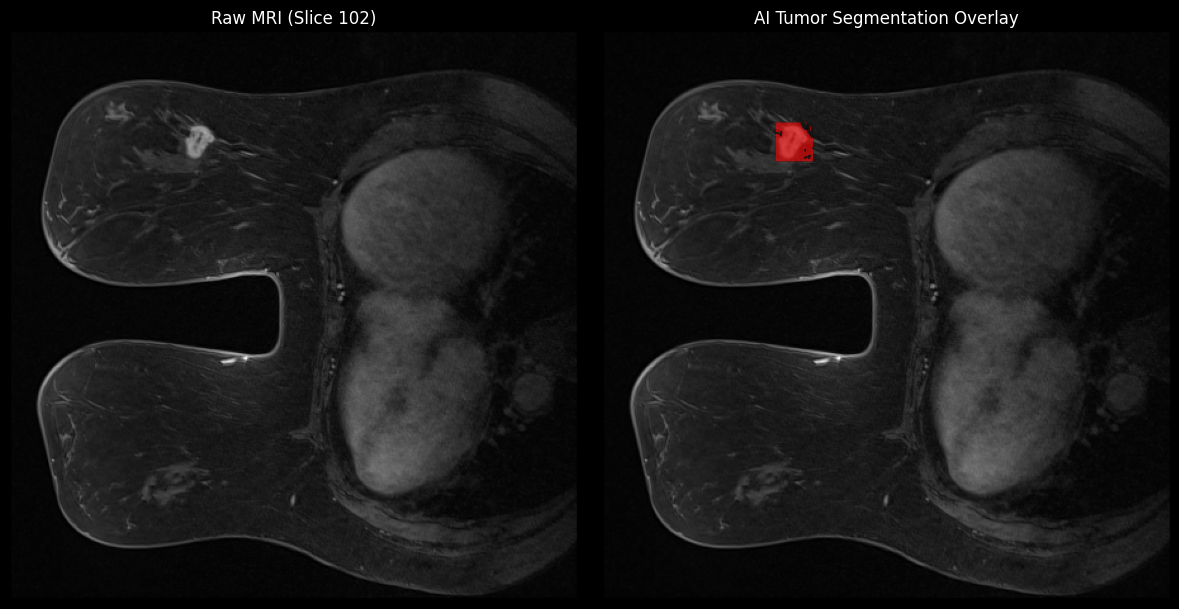


Generating Texture Heatmap for Processed NIFTI Dataset\Breast_MRI_201\post_1.img.gz...


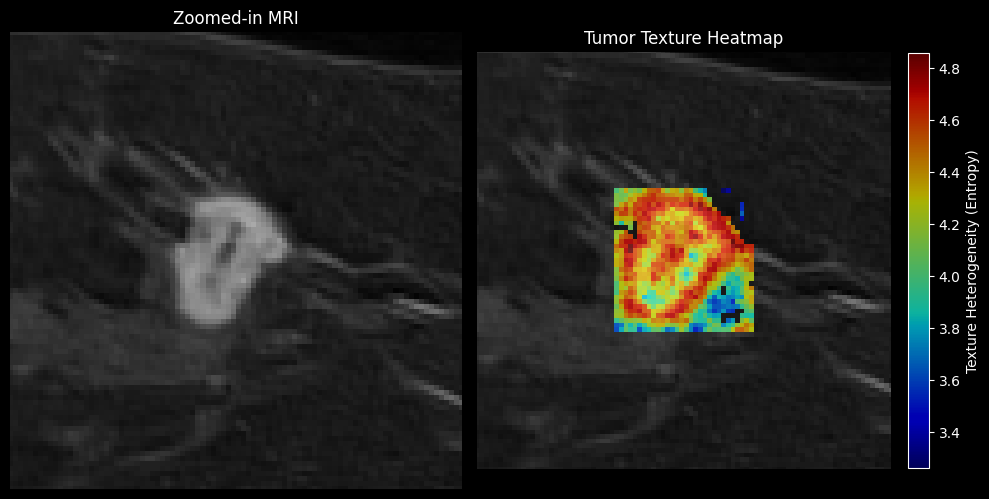


Generating AI Feature Importance Chart...


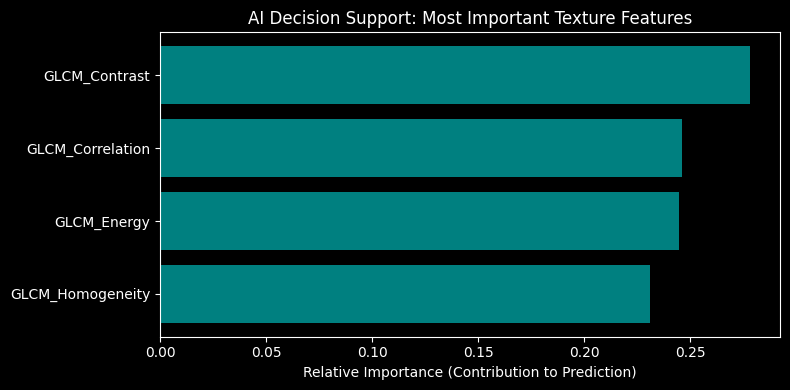

In [7]:

# =============================================================================
# 4. VISUALIZATION: MRI SLICE WITH TUMOR OVERLAY
# ==============================================================================
# Notice how this is dedented back to the left wall!
def visualize_tumor(image_path, mask_path):
    print(f"\nGenerating visual for {image_path}...")

    # Load data
    img_data = nib.load(image_path).get_fdata()
    mask_data = nib.load(mask_path).get_fdata()

    # Find the best slice
    slice_areas = np.sum(mask_data, axis=(0, 1))
    best_slice_idx = np.argmax(slice_areas)

    # Extract 2D slices
    img_slice = img_data[:, :, best_slice_idx]
    mask_slice = mask_data[:, :, best_slice_idx]

    # Set up the plot
    plt.figure(figsize=(12, 6))

    # Left Image: Raw MRI
    plt.subplot(1, 2, 1)
    plt.imshow(img_slice, cmap='gray')
    plt.title(f'Raw MRI (Slice {best_slice_idx})')
    plt.axis('off')

    # Right Image: MRI + Tumor Overlay
    plt.subplot(1, 2, 2)
    plt.imshow(img_slice, cmap='gray')

    # Create a transparency mask so we only highlight the tumor in red
    masked_tumor = np.ma.masked_where(mask_slice == 0, mask_slice)
    plt.imshow(masked_tumor, cmap='autumn', alpha=0.6)

    plt.title('AI Tumor Segmentation Overlay')
    plt.axis('off')

    plt.tight_layout()
    plt.show()

# Run the visualization!
visualize_tumor(
    r"Processed NIFTI Dataset\Breast_MRI_201\post_1.img.gz",
    r"Processed NIFTI Dataset\Breast_MRI_201\segmentation.img.gz"
)


from skimage.filters.rank import entropy
from skimage.morphology import disk

# ==============================================================================
# 5. VISUALIZATION: TEXTURE HEATMAP
# ==============================================================================
def visualize_texture_heatmap(image_path, mask_path):
    print(f"\nGenerating Texture Heatmap for {image_path}...")

    # Load the data
    img_data = nib.load(image_path).get_fdata()
    mask_data = nib.load(mask_path).get_fdata()

    # Find the best slice
    slice_areas = np.sum(mask_data, axis=(0, 1))
    best_slice_idx = np.argmax(slice_areas)

    img_slice = img_data[:, :, best_slice_idx]
    mask_slice = mask_data[:, :, best_slice_idx]

    # Convert to 8-bit image for the entropy filter
    img_normalized = np.interp(img_slice, (img_slice.min(), img_slice.max()), (0, 255)).astype('uint8')

    # Calculate Local Entropy (Texture Chaos) across the image
    texture_map = entropy(img_normalized, disk(3))

    # Create a mask so the heatmap ONLY shows up inside the tumor
    masked_texture = np.ma.masked_where(mask_slice == 0, texture_map)

    # Set up the plot
    plt.figure(figsize=(10, 5))

    # Left: The Raw Tumor
    plt.subplot(1, 2, 1)
    plt.imshow(img_slice, cmap='gray')

    # We will "zoom in" on the tumor so it looks better on the slides
    coords = np.argwhere(mask_slice)
    if len(coords) > 0:
        y0, x0 = coords.min(axis=0)
        y1, x1 = coords.max(axis=0)
        plt.ylim(y1 + 30, y0 - 30) # Zoom bounding box
        plt.xlim(x0 - 30, x1 + 30)

    plt.title('Zoomed-in MRI')
    plt.axis('off')

    # Right: The Texture Heatmap
    plt.subplot(1, 2, 2)
    plt.imshow(img_slice, cmap='gray')
    heat = plt.imshow(masked_texture, cmap='jet', alpha=0.7) # 'jet' makes it colorful (blue to red)
    plt.colorbar(heat, fraction=0.046, pad=0.04, label="Texture Heterogeneity (Entropy)")

    if len(coords) > 0:
        plt.ylim(y1 + 30, y0 - 30)
        plt.xlim(x0 - 30, x1 + 30)

    plt.title('Tumor Texture Heatmap')
    plt.axis('off')

    plt.tight_layout()
    plt.show()

# Run the Heatmap Visual
visualize_texture_heatmap(
    r"Processed NIFTI Dataset\Breast_MRI_201\post_1.img.gz",
    r"Processed NIFTI Dataset\Breast_MRI_201\segmentation.img.gz"
)

# ==============================================================================
# 6. VISUALIZATION: AI "BRAIN" (FEATURE IMPORTANCE)
# ==============================================================================
# We wrap this in a try/except just in case the AI skipped training earlier
try:
    if 'ai_model' in locals():
        print("\nGenerating AI Feature Importance Chart...")
        importances = ai_model.feature_importances_
        feature_names = X.columns

        # Sort them so the biggest bar is at the top
        indices = np.argsort(importances)

        plt.figure(figsize=(8, 4))
        plt.title('AI Decision Support: Most Important Texture Features')
        plt.barh(range(len(indices)), importances[indices], color='teal', align='center')
        plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
        plt.xlabel('Relative Importance (Contribution to Prediction)')

        plt.tight_layout()
        plt.show()
except Exception as e:
    print(f"Could not plot feature importance: {e}")